<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_KiDS_Pgk_Boundary_Response_V3c_LowRAM_DOWNLOAD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM KiDS Pgk Boundary Response V3c — LOW-RAM download/reproduction notebook

This is the fixed low-RAM replacement for V3/V3b.

**What changed:** the earlier notebook crashed because the nested boundary scan built a huge Python list/DataFrame of every trial template. V3c streams the scan, keeps only the current best and a small top-N audit table, and uses the same boundary-kernel registry for selection, reproduction, null tests, and validation.

**Scientific guardrail:** this remains a covariance-aware shape/transfer test of a boundary-response term in the KiDS-1000 `PneE` galaxy--galaxy lensing bandpower vector. It is not yet a first-principles baryonic-driver projection integral.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# CELL 01 — Setup: low-RAM output directories and imports

import os, json, zipfile, shutil, urllib.request, math, heapq, gc
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from astropy.io import fits
except Exception:
    import sys, subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'astropy'])
    from astropy.io import fits

RUN_LABEL = 'ECSM_KiDS_Pgk_Boundary_Response_V3c_LowRAM_FixedRegistry'
BASE = Path('/content')
OUT = BASE / 'ecsm_kids_pgk_boundary_response_v3c_lowram_out'
TAB = OUT / 'tables'
FIG = OUT / 'figures'
DATA = OUT / 'data'
for d in [OUT, TAB, FIG, DATA]:
    d.mkdir(parents=True, exist_ok=True)

print('Output:', OUT)


Output: /content/ecsm_kids_pgk_boundary_response_v3c_lowram_out


In [3]:
# CELL 02 — Download KiDS-WL Cat_to_Obs_K1000_P1 repository directly

REPO_ZIP_URL = 'https://github.com/KiDS-WL/Cat_to_Obs_K1000_P1/archive/refs/heads/master.zip'
ZIP_PATH = DATA / 'Cat_to_Obs_K1000_P1-master.zip'
REPO_PARENT = DATA / 'Cat_to_Obs_K1000_P1_repo'

if not ZIP_PATH.exists():
    print('Downloading:', REPO_ZIP_URL)
    urllib.request.urlretrieve(REPO_ZIP_URL, ZIP_PATH)
else:
    print('Using cached zip:', ZIP_PATH)

if not REPO_PARENT.exists():
    REPO_PARENT.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(REPO_PARENT)

roots = sorted(REPO_PARENT.glob('Cat_to_Obs_K1000_P1-*'))
assert roots, 'Repository root not found after extraction.'
REPO_ROOT = roots[0]
print('Repository root:', REPO_ROOT)


Downloading: https://github.com/KiDS-WL/Cat_to_Obs_K1000_P1/archive/refs/heads/master.zip
Repository root: /content/ecsm_kids_pgk_boundary_response_v3c_lowram_out/data/Cat_to_Obs_K1000_P1_repo/Cat_to_Obs_K1000_P1-master


In [4]:
# CELL 03 — Load KiDS-1000 PneE/Pgk data vector and covariance from final iterative covariance FITS

fits_candidates = sorted((REPO_ROOT/'data'/'kids'/'fits_iterative_covariance').glob('bp_KIDS1000_BlindC_with_m_bias*.fits'))
assert fits_candidates, 'Preferred final iterative covariance BP FITS file not found.'
FITS_PATH = fits_candidates[0]
print('Using FITS:', FITS_PATH)

with fits.open(FITS_PATH) as hdul:
    cov_full = np.array(hdul['COVMAT'].data, dtype='<f8')
    pne = hdul['PneE'].data
    nz_lens = hdul['NZ_LENS'].data
    nz_source = hdul['NZ_SOURCE'].data

# PneE occupies the first 80 rows/cols in the 200x200 BP covariance.
cov = np.array(cov_full[:len(pne), :len(pne)], dtype=float)

df = pd.DataFrame({
    'lens_bin': np.array(pne['BIN1'], dtype=int),
    'source_bin': np.array(pne['BIN2'], dtype=int),
    'ell_bin': np.array(pne['ANGBIN'], dtype=int),
    'Pgk_E': np.array(pne['VALUE'], dtype=float),
    'ell': np.array(pne['ANG'], dtype=float),
})
df['vec_index'] = np.arange(len(df), dtype=int)
df['sigma_diag'] = np.sqrt(np.clip(np.diag(cov), 0, np.inf))

lens_bounds = {1:(0.20,0.50), 2:(0.50,0.75)}
df['lens_z_min'] = df['lens_bin'].map(lambda b: lens_bounds[int(b)][0])
df['lens_z_max'] = df['lens_bin'].map(lambda b: lens_bounds[int(b)][1])
df['lens_z_eff_simple'] = 0.5*(df['lens_z_min'] + df['lens_z_max'])

np.save(DATA/'kids1000_Pgk_PneE_covariance.npy', cov)
df.to_csv(TAB/'kids1000_Pgk_PneE_observed_vector_with_errors.csv', index=False)

block_manifest = (df.groupby(['lens_bin','source_bin'], as_index=False)
    .agg(N_ell=('ell','size'), ell_min=('ell','min'), ell_max=('ell','max'),
         lens_z_min=('lens_z_min','first'), lens_z_max=('lens_z_max','first'),
         vec_start=('vec_index','min'), vec_end=('vec_index','max'),
         mean_abs_Pgk=('Pgk_E', lambda x: float(np.mean(np.abs(x)))),
         max_abs_Pgk=('Pgk_E', lambda x: float(np.max(np.abs(x)))),
         mean_sigma_diag=('sigma_diag','mean')))
block_manifest['lens_z_eff_simple'] = 0.5*(block_manifest['lens_z_min'] + block_manifest['lens_z_max'])
block_manifest.to_csv(TAB/'kids1000_Pgk_PneE_block_manifest.csv', index=False)

print('N:', len(df), 'Cov:', cov.shape)
display(df.head())
display(block_manifest)


Using FITS: /content/ecsm_kids_pgk_boundary_response_v3c_lowram_out/data/Cat_to_Obs_K1000_P1_repo/Cat_to_Obs_K1000_P1-master/data/kids/fits_iterative_covariance/bp_KIDS1000_BlindC_with_m_bias_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits
N: 80 Cov: (80, 80)


,lens_bin,source_bin,ell_bin,Pgk_E,ell,vec_index,sigma_diag,lens_z_min,lens_z_max,lens_z_eff_simple
0,1,1,1,-0.001103,118.441992,0,0.000528,0.2,0.5,0.35
1,1,1,2,-0.000134,166.156414,1,0.000685,0.2,0.5,0.35
2,1,1,3,-0.000622,233.092617,2,0.000852,0.2,0.5,0.35
3,1,1,4,0.001396,326.994107,3,0.001095,0.2,0.5,0.35
4,1,1,5,0.001722,458.723863,4,0.001446,0.2,0.5,0.35


,lens_bin,source_bin,N_ell,ell_min,ell_max,lens_z_min,lens_z_max,vec_start,vec_end,mean_abs_Pgk,max_abs_Pgk,mean_sigma_diag,lens_z_eff_simple
0,1,1,8,118.441992,1266.44273,0.2,0.50,0,7,0.001478,0.004073,0.001596,0.350
1,1,2,8,118.441992,1266.44273,0.2,0.50,8,15,0.001862,0.003893,0.001077,0.350
2,1,3,8,118.441992,1266.44273,0.2,0.50,16,23,0.004531,0.012985,0.000922,0.350
3,1,4,8,118.441992,1266.44273,0.2,0.50,24,31,0.009082,0.025726,0.001043,0.350
4,1,5,8,118.441992,1266.44273,0.2,0.50,32,39,0.011094,0.030537,0.001086,0.350
5,2,1,8,118.441992,1266.44273,0.5,0.75,40,47,0.001927,0.005373,0.001531,0.625
6,2,2,8,118.441992,1266.44273,0.5,0.75,48,55,0.000899,0.002192,0.001035,0.625
7,2,3,8,118.441992,1266.44273,0.5,0.75,56,63,0.000903,0.003121,0.000874,0.625
8,2,4,8,118.441992,1266.44273,0.5,0.75,64,71,0.003595,0.007450,0.000989,0.625
9,2,5,8,118.441992,1266.44273,0.5,0.75,72,79,0.006584,0.021043,0.001038,0.625


,min_eigenvalue,max_eigenvalue,condition_positive,N
0,9.539910e-08,0.000013,135.58015,80


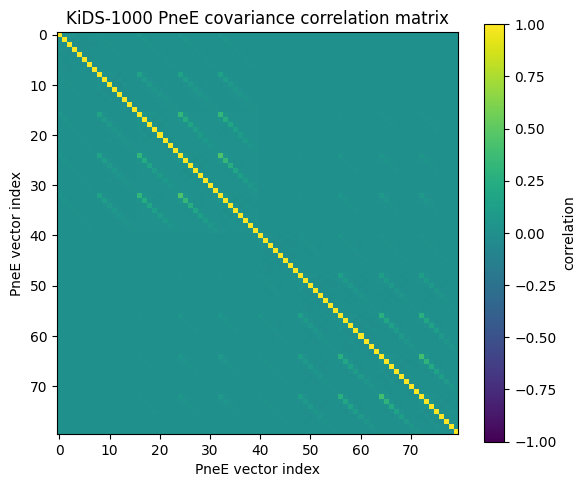

In [5]:
# CELL 04 — Covariance diagnostics and correlation matrix

eigvals = np.linalg.eigvalsh(cov)
condition_positive = float(eigvals.max()/eigvals[eigvals>0].min())
cov_diag = pd.DataFrame([{
    'min_eigenvalue': float(eigvals.min()),
    'max_eigenvalue': float(eigvals.max()),
    'condition_positive': condition_positive,
    'N': len(df),
}])
cov_diag.to_csv(TAB/'covariance_diagnostics.csv', index=False)
display(cov_diag)

diag = np.sqrt(np.clip(np.diag(cov), 0, np.inf))
with np.errstate(divide='ignore', invalid='ignore'):
    corr = cov / np.outer(diag, diag)
corr[~np.isfinite(corr)] = 0

plt.figure(figsize=(6,5))
plt.imshow(corr, vmin=-1, vmax=1, origin='upper')
plt.colorbar(label='correlation')
plt.xlabel('PneE vector index')
plt.ylabel('PneE vector index')
plt.title('KiDS-1000 PneE covariance correlation matrix')
plt.tight_layout()
plt.savefig(FIG/'kids1000_Pgk_PneE_covariance_correlation.png', dpi=180)
plt.show()


In [6]:
# CELL 05 — Geometry proxy and low-RAM model utilities

# Build a simple source/lens redshift-overlap geometry proxy from the FITS NZ tables.
z_l = np.array(nz_lens['Z_MID'], dtype=float)
z_s = np.array(nz_source['Z_MID'], dtype=float)

def norm_nz(z, n):
    n = np.clip(np.asarray(n, dtype=float), 0, np.inf)
    area = np.trapezoid(n, z) if len(z) > 1 else n.sum()
    return n/area if area > 0 else n

geom_rows=[]
for lb in [1,2]:
    nl = norm_nz(z_l, np.array(nz_lens[f'BIN{lb}'], dtype=float))
    for sb in [1,2,3,4,5]:
        ns = norm_nz(z_s, np.array(nz_source[f'BIN{sb}'], dtype=float))
        # ECSM-neutral proxy: lens-source overlap weighted by positive background separation.
        K = np.maximum(z_s[None, :] - z_l[:, None], 0.0) / (1.0 + z_s[None, :])
        val = np.trapezoid(np.trapezoid(nl[:,None]*ns[None,:]*K, z_s, axis=1), z_l)
        geom_rows.append({'lens_bin': lb, 'source_bin': sb, 'G_lens_source': float(val), 'geometry_source':'NZ_LENS/NZ_SOURCE integral proxy'})
geom_df = pd.DataFrame(geom_rows)
geom_df.to_csv(TAB/'geometry_proxy.csv', index=False)
display(geom_df)

# Attach G to every vector row.
df2 = df.merge(geom_df[['lens_bin','source_bin','G_lens_source']], on=['lens_bin','source_bin'], how='left')
y = df2['Pgk_E'].to_numpy(float)
ell = df2['ell'].to_numpy(float)
G = df2['G_lens_source'].to_numpy(float)
ell0 = float(np.exp(np.mean(np.log(ell))))
print('ell0:', ell0)

# Cholesky inverse action: stable and cheap for N=80.
L = np.linalg.cholesky(cov + np.eye(len(cov))*1e-15)

def cinv_dot(v):
    return np.linalg.solve(L.T, np.linalg.solve(L, v))

Ciy = cinv_dot(y)
yCiy = float(y @ Ciy)

def fit_amplitude(template, mask=None):
    template = np.asarray(template, dtype=float)
    if mask is None:
        t = template; yy = y; Cinv_y = Ciy
        Cinv_t = cinv_dot(t)
        den = float(t @ Cinv_t)
        if den <= 0 or not np.isfinite(den):
            return 0.0, np.inf, np.zeros_like(t)
        A = float((t @ Cinv_y)/den)
        resid = yy - A*t
        chi2 = float(resid @ cinv_dot(resid))
        return A, chi2, A*t
    else:
        idx = np.where(mask)[0]
        cc = cov[np.ix_(idx, idx)]
        yy = y[idx]
        tt = template[idx]
        LL = np.linalg.cholesky(cc + np.eye(len(idx))*1e-15)
        def sub_cinv(v):
            return np.linalg.solve(LL.T, np.linalg.solve(LL, v))
        Ciyy = sub_cinv(yy)
        Citt = sub_cinv(tt)
        den = float(tt @ Citt)
        if den <= 0 or not np.isfinite(den):
            return 0.0, np.inf, np.zeros_like(tt)
        A = float((tt @ Ciyy)/den)
        resid = yy - A*tt
        chi2 = float(resid @ sub_cinv(resid))
        return A, chi2, A*tt

def chi2_vec(resid, mask=None):
    resid = np.asarray(resid, dtype=float)
    if mask is None:
        return float(resid @ cinv_dot(resid))
    idx = np.where(mask)[0]
    cc = cov[np.ix_(idx, idx)]
    rr = resid[idx]
    LL = np.linalg.cholesky(cc + np.eye(len(idx))*1e-15)
    vv = np.linalg.solve(LL.T, np.linalg.solve(LL, rr))
    return float(rr @ vv)

def boundary_kernel(kind, ell, ell_B, p):
    x = np.maximum(np.asarray(ell, dtype=float), 1e-12) / float(ell_B)
    p = float(p)
    if kind == 'low_suppression':
        return 1.0/(1.0 + x**p)
    if kind == 'high_suppression':
        return x**p/(1.0 + x**p)
    if kind == 'signed_transition':
        return (x**p - 1.0)/(x**p + 1.0)
    if kind == 'log_bump':
        return np.exp(-0.5*(np.log(x)/0.75)**2)
    raise ValueError(f'Unknown boundary kernel: {kind}')

def template_m1(mask=None):
    return G.copy()

def template_m2(alpha):
    return G * (ell/ell0)**float(alpha)

def template_m3(alpha, kind, ell_B, p, B):
    T = boundary_kernel(kind, ell, ell_B, p)
    return G * (ell/ell0)**float(alpha) * (1.0 + float(B)*T)

def scan_model(template_func, grid_iter, top_n=30, mask=None):
    # Streaming scan: keeps only best row and small top-N list. No million-row DataFrame.
    best = None
    heap = []
    n = 0
    for params in grid_iter:
        templ = template_func(**params)
        A, chi2, _ = fit_amplitude(templ, mask=mask)
        if not np.isfinite(chi2):
            continue
        row = dict(params)
        row.update({'A': float(A), 'chi2': float(chi2)})
        if best is None or chi2 < best['chi2']:
            best = row
        # max-heap by negative chi2 to keep top low chi2
        item = (-chi2, n, row)
        if len(heap) < top_n:
            heapq.heappush(heap, item)
        elif item[0] > heap[0][0]:
            heapq.heapreplace(heap, item)
        n += 1
    top = [r for _,_,r in sorted(heap, key=lambda z: -z[0])]
    return pd.DataFrame(top).sort_values('chi2').reset_index(drop=True), best, n

print('Utilities ready. No full-grid rows will be stored.')


,lens_bin,source_bin,G_lens_source,geometry_source
0,1,1,0.013812,NZ_LENS/NZ_SOURCE integral proxy
1,1,2,0.042435,NZ_LENS/NZ_SOURCE integral proxy
2,1,3,0.116030,NZ_LENS/NZ_SOURCE integral proxy
3,1,4,0.222507,NZ_LENS/NZ_SOURCE integral proxy
4,1,5,0.292604,NZ_LENS/NZ_SOURCE integral proxy
5,2,1,0.003665,NZ_LENS/NZ_SOURCE integral proxy
6,2,2,0.004937,NZ_LENS/NZ_SOURCE integral proxy
7,2,3,0.030559,NZ_LENS/NZ_SOURCE integral proxy
8,2,4,0.112763,NZ_LENS/NZ_SOURCE integral proxy
9,2,5,0.191535,NZ_LENS/NZ_SOURCE integral proxy


ell0: 387.29833462074157
Utilities ready. No full-grid rows will be stored.


In [7]:
# CELL 06 — Full-data competition with fixed low-RAM boundary registry

alpha_grid = np.round(np.linspace(0.50, 1.70, 49), 6)
ellB_grid = np.geomspace(20.0, 1500.0, 55)
p_grid = [1.0, 2.0, 3.0, 4.0]
B_grid = np.round(np.linspace(-2.0, 2.0, 41), 6)
kinds = ['low_suppression', 'high_suppression', 'signed_transition', 'log_bump']

# M0
chi2_zero = chi2_vec(y)

# M1
A1, chi2_m1, pred_m1 = fit_amplitude(template_m1())

# M2 smooth powerlaw
def m2_iter():
    for alpha in alpha_grid:
        yield {'alpha': float(alpha)}

m2_top, m2_best, n_m2 = scan_model(lambda alpha: template_m2(alpha), m2_iter(), top_n=20)
pred_m2 = m2_best['A'] * template_m2(m2_best['alpha'])

# M3 nested boundary. This scans 49*55*4*41*4 = 1,767,920 templates without storing them.
def m3_iter():
    for kind in kinds:
        for alpha in alpha_grid:
            for ell_B in ellB_grid:
                for p in p_grid:
                    for B in B_grid:
                        yield {'kind': kind, 'alpha': float(alpha), 'ell_B': float(ell_B), 'p': float(p), 'B': float(B)}

m3_top, m3_best, n_m3 = scan_model(lambda kind, alpha, ell_B, p, B: template_m3(alpha, kind, ell_B, p, B),
                                  m3_iter(), top_n=50)
pred_m3 = m3_best['A'] * template_m3(m3_best['alpha'], m3_best['kind'], m3_best['ell_B'], m3_best['p'], m3_best['B'])

# Freeze exact selected boundary function and parameters for all downstream audit cells.
FROZEN_BOUNDARY = {k: m3_best[k] for k in ['kind','ell_B','p','B']}

res_rows = [
    {'model':'M3_selected_boundary', 'family':'ECSM_boundary_registry', 'chi2':m3_best['chi2'], 'n_params':5, 'params':json.dumps({**m3_best, 'frozen_boundary':FROZEN_BOUNDARY})},
    {'model':'M2_smooth_powerlaw', 'family':'smooth_control', 'chi2':m2_best['chi2'], 'n_params':2, 'params':json.dumps(m2_best)},
    {'model':'M1_geometry_constant', 'family':'geometry', 'chi2':chi2_m1, 'n_params':1, 'params':json.dumps({'A':A1})},
    {'model':'M0_zero', 'family':'null', 'chi2':chi2_zero, 'n_params':0, 'params':json.dumps({})},
]
res_df = pd.DataFrame(res_rows).sort_values('chi2').reset_index(drop=True)
N = len(df2)
res_df['AIC'] = res_df['chi2'] + 2*res_df['n_params']
res_df['BIC'] = res_df['chi2'] + np.log(N)*res_df['n_params']
zero_chi2 = float(res_df.loc[res_df.model=='M0_zero','chi2'].iloc[0])
smooth_chi2 = float(res_df.loc[res_df.model=='M2_smooth_powerlaw','chi2'].iloc[0])
smooth_aic = float(res_df.loc[res_df.model=='M2_smooth_powerlaw','AIC'].iloc[0])
smooth_bic = float(res_df.loc[res_df.model=='M2_smooth_powerlaw','BIC'].iloc[0])
res_df['delta_chi2_vs_zero'] = zero_chi2 - res_df['chi2']
res_df['delta_chi2_vs_smooth'] = smooth_chi2 - res_df['chi2']
res_df['delta_AIC_vs_smooth'] = smooth_aic - res_df['AIC']
res_df['delta_BIC_vs_smooth'] = smooth_bic - res_df['BIC']

res_df.to_csv(TAB/'full_data_model_competition.csv', index=False)
m2_top.to_csv(TAB/'top_smooth_powerlaw_scan_rows.csv', index=False)
m3_top.to_csv(TAB/'top_boundary_registry_scan_rows_LOW_RAM.csv', index=False)
with open(TAB/'frozen_boundary_registry.json', 'w') as f:
    json.dump(FROZEN_BOUNDARY, f, indent=2)

print('Scanned M2 templates:', n_m2)
print('Scanned M3 templates without storing all rows:', n_m3)
print('Frozen boundary:', FROZEN_BOUNDARY)
display(res_df)
display(m3_top.head(10))

gc.collect()


Scanned M2 templates: 49
Scanned M3 templates without storing all rows: 1767920
Frozen boundary: {'kind': 'high_suppression', 'ell_B': 77.86226983114605, 'p': 3.0, 'B': -0.9}


,model,family,chi2,n_params,params,AIC,BIC,delta_chi2_vs_zero,delta_chi2_vs_smooth,delta_AIC_vs_smooth,delta_BIC_vs_smooth
0,M3_selected_boundary,ECSM_boundary_registry,113.807587,5,"{""kind"": ""high_suppression"", ""alpha"": 1.325, ""...",123.807587,135.717720,1231.590661,32.802204,26.802204,19.656124
1,M2_smooth_powerlaw,smooth_control,146.609791,2,"{""alpha"": 1.05, ""A"": 0.026855027604864048, ""ch...",150.609791,155.373844,1198.788458,0.000000,0.000000,0.000000
2,M1_geometry_constant,geometry,640.991179,1,"{""A"": 0.019540640823064354}",642.991179,645.373206,704.407069,-494.381388,-492.381388,-489.999362
3,M0_zero,null,1345.398248,0,{},1345.398248,1345.398248,0.000000,-1198.788458,-1194.788458,-1190.024404


,kind,alpha,ell_B,p,B,A,chi2
0,high_suppression,1.325,77.862270,3.0,-0.9,0.214349,113.807587
1,signed_transition,1.350,84.343267,3.0,-0.8,0.105006,113.913174
2,signed_transition,1.350,61.257179,3.0,-0.9,0.210837,114.000833
3,signed_transition,1.300,56.550133,3.0,-0.9,0.220340,114.004672
4,signed_transition,1.300,77.862270,3.0,-0.8,0.109615,114.021119
5,signed_transition,1.325,61.257179,3.0,-0.9,0.213298,114.078021
6,high_suppression,1.300,116.129844,4.0,-0.8,0.110219,114.116402
7,signed_transition,1.275,56.550133,3.0,-0.9,0.222901,114.119378
8,signed_transition,1.325,84.343267,3.0,-0.8,0.106214,114.132861
9,high_suppression,1.375,84.343267,3.0,-0.9,0.204958,114.146999


5938

In [8]:
# CELL 07 — Reproduction audit and null tests using the exact same boundary registry

# Audit: refit only A and alpha while keeping selected kind/ell_B/p/B frozen.
def frozen_iter():
    for alpha in alpha_grid:
        yield {'alpha': float(alpha)}

def frozen_template(alpha, boundary=None, G_override=None):
    b = boundary or FROZEN_BOUNDARY
    GG = G if G_override is None else G_override
    T = boundary_kernel(b['kind'], ell, b['ell_B'], b['p'])
    return GG * (ell/ell0)**float(alpha) * (1.0 + float(b['B'])*T)

frozen_top, frozen_best, n_frozen = scan_model(lambda alpha: frozen_template(alpha), frozen_iter(), top_n=20)

# Wrong-boundary nulls: same registry, deliberately shifted boundary scale.
wrong_low = dict(FROZEN_BOUNDARY); wrong_low['ell_B'] = FROZEN_BOUNDARY['ell_B']/3.0
wrong_high = dict(FROZEN_BOUNDARY); wrong_high['ell_B'] = FROZEN_BOUNDARY['ell_B']*3.0

wrong_low_top, wrong_low_best, _ = scan_model(lambda alpha: frozen_template(alpha, wrong_low), frozen_iter(), top_n=5)
wrong_high_top, wrong_high_best, _ = scan_model(lambda alpha: frozen_template(alpha, wrong_high), frozen_iter(), top_n=5)

# Shuffled geometry null keeps ell shape but destroys lens/source ordering.
rng = np.random.default_rng(12345)
G_shuffled = rng.permutation(G)
shuf_top, shuf_best, _ = scan_model(lambda alpha: frozen_template(alpha, FROZEN_BOUNDARY, G_override=G_shuffled), frozen_iter(), top_n=5)

null_df = pd.DataFrame([
    {'test':'smooth_powerlaw_control', 'chi2':m2_best['chi2'], 'params':json.dumps(m2_best)},
    {'test':'selected_boundary_original_scan', 'chi2':m3_best['chi2'], 'params':json.dumps(m3_best)},
    {'test':'reproduced_frozen_boundary_same_registry', 'chi2':frozen_best['chi2'], 'params':json.dumps({**frozen_best, **FROZEN_BOUNDARY})},
    {'test':'wrong_boundary_low', 'chi2':wrong_low_best['chi2'], 'params':json.dumps({**wrong_low_best, **wrong_low})},
    {'test':'wrong_boundary_high', 'chi2':wrong_high_best['chi2'], 'params':json.dumps({**wrong_high_best, **wrong_high})},
    {'test':'shuffled_source_geometry', 'chi2':shuf_best['chi2'], 'params':json.dumps({**shuf_best, **FROZEN_BOUNDARY})},
])
correct = float(null_df.loc[null_df.test=='reproduced_frozen_boundary_same_registry','chi2'].iloc[0])
null_df['delta_chi2_vs_reproduced_frozen_boundary'] = correct - null_df['chi2']
null_df['delta_chi2_vs_smooth'] = float(m2_best['chi2']) - null_df['chi2']
null_df.to_csv(TAB/'boundary_reproduction_and_null_tests.csv', index=False)

display(null_df)


,test,chi2,params,delta_chi2_vs_reproduced_frozen_boundary,delta_chi2_vs_smooth
0,smooth_powerlaw_control,146.609791,"{""alpha"": 1.05, ""A"": 0.026855027604864048, ""ch...",-32.802204,0.000000
1,selected_boundary_original_scan,113.807587,"{""kind"": ""high_suppression"", ""alpha"": 1.325, ""...",0.000000,32.802204
2,reproduced_frozen_boundary_same_registry,113.807587,"{""alpha"": 1.325, ""A"": 0.214348740812595, ""chi2...",0.000000,32.802204
3,wrong_boundary_low,141.913863,"{""alpha"": 1.075, ""A"": 0.2645550235233095, ""chi...",-28.106276,4.695928
4,wrong_boundary_high,222.892552,"{""alpha"": 1.7, ""A"": 0.10077035236505102, ""chi2...",-109.084965,-76.282762
5,shuffled_source_geometry,1062.619167,"{""alpha"": 1.7, ""A"": 0.06683116946914157, ""chi2...",-948.811580,-916.009376


In [9]:
# CELL 08 — Held-out validation: source-bin and lens-bin transfer with frozen selected boundary

def fit_smooth_on_mask(train_mask):
    best = None
    for alpha in alpha_grid:
        templ = template_m2(alpha)
        A, chi2, _ = fit_amplitude(templ, mask=train_mask)
        if best is None or chi2 < best['chi2_train']:
            best = {'A':float(A), 'alpha':float(alpha), 'chi2_train':float(chi2)}
    return best

def fit_frozen_on_mask(train_mask):
    best = None
    for alpha in alpha_grid:
        templ = frozen_template(alpha)
        A, chi2, _ = fit_amplitude(templ, mask=train_mask)
        if best is None or chi2 < best['chi2_train']:
            best = {'A':float(A), 'alpha':float(alpha), 'chi2_train':float(chi2), **FROZEN_BOUNDARY}
    return best

def fit_m1_on_mask(train_mask):
    A, chi2, _ = fit_amplitude(template_m1(), mask=train_mask)
    return {'A':float(A), 'chi2_train':float(chi2)}

def eval_pred(params, model, test_mask):
    if model == 'M0_zero':
        pred = np.zeros_like(y)
    elif model == 'M1_geometry_constant':
        pred = params['A'] * template_m1()
    elif model == 'M2_smooth_powerlaw':
        pred = params['A'] * template_m2(params['alpha'])
    elif model == 'M3_frozen_boundary':
        pred = params['A'] * frozen_template(params['alpha'])
    else:
        raise ValueError(model)
    return chi2_vec(y - pred, mask=test_mask)

def heldout_by(column):
    rows=[]
    for held in sorted(df2[column].unique()):
        test_mask = (df2[column].to_numpy() == held)
        train_mask = ~test_mask
        smooth = fit_smooth_on_mask(train_mask)
        frozen = fit_frozen_on_mask(train_mask)
        m1 = fit_m1_on_mask(train_mask)
        zero_test = chi2_vec(y, mask=test_mask)
        models = {
            'M0_zero': {},
            'M1_geometry_constant': m1,
            'M2_smooth_powerlaw': smooth,
            'M3_frozen_boundary': frozen,
        }
        smooth_test = eval_pred(smooth, 'M2_smooth_powerlaw', test_mask)
        for name, params in models.items():
            chi2_test = zero_test if name == 'M0_zero' else eval_pred(params, name, test_mask)
            rows.append({
                'split_column': column,
                'held_out': int(held),
                'model': name,
                'chi2_test': float(chi2_test),
                'chi2_test_zero': float(zero_test),
                'chi2_test_smooth': float(smooth_test),
                'delta_chi2_test_vs_zero': float(zero_test - chi2_test),
                'delta_chi2_test_vs_smooth': float(smooth_test - chi2_test),
                'n_train': int(train_mask.sum()),
                'n_test': int(test_mask.sum()),
                'params': json.dumps(params),
            })
    detail = pd.DataFrame(rows)
    summary = (detail.groupby('model', as_index=False)
               .agg(total_test_chi2=('chi2_test','sum'),
                    total_zero_chi2=('chi2_test_zero','sum'),
                    total_smooth_chi2=('chi2_test_smooth','sum'),
                    total_delta_chi2_vs_zero=('delta_chi2_test_vs_zero','sum'),
                    total_delta_chi2_vs_smooth=('delta_chi2_test_vs_smooth','sum'),
                    mean_delta_chi2_vs_zero=('delta_chi2_test_vs_zero','mean'),
                    mean_delta_chi2_vs_smooth=('delta_chi2_test_vs_smooth','mean'),
                    frac_folds_positive_vs_zero=('delta_chi2_test_vs_zero', lambda x: float(np.mean(np.asarray(x)>0))),
                    frac_folds_positive_vs_smooth=('delta_chi2_test_vs_smooth', lambda x: float(np.mean(np.asarray(x)>0)))))
    summary['fractional_improvement_vs_zero'] = 1.0 - summary['total_test_chi2']/summary['total_zero_chi2']
    return detail, summary.sort_values('total_test_chi2').reset_index(drop=True)

source_cv_detail, source_cv_summary = heldout_by('source_bin')
lens_cv_detail, lens_cv_summary = heldout_by('lens_bin')

source_cv_detail.to_csv(TAB/'heldout_sourcebin_detail.csv', index=False)
source_cv_summary.to_csv(TAB/'heldout_sourcebin_summary.csv', index=False)
lens_cv_detail.to_csv(TAB/'heldout_lensbin_detail.csv', index=False)
lens_cv_summary.to_csv(TAB/'heldout_lensbin_summary.csv', index=False)

print('Held-out source-bin summary')
display(source_cv_summary)
print('Held-out lens-bin summary')
display(lens_cv_summary)


Held-out source-bin summary


,model,total_test_chi2,total_zero_chi2,total_smooth_chi2,total_delta_chi2_vs_zero,total_delta_chi2_vs_smooth,mean_delta_chi2_vs_zero,mean_delta_chi2_vs_smooth,frac_folds_positive_vs_zero,frac_folds_positive_vs_smooth,fractional_improvement_vs_zero
0,M3_frozen_boundary,113.004670,1685.378416,155.149708,1572.373746,42.145038,314.474749,8.429008,0.8,0.6,0.932950
1,M2_smooth_powerlaw,155.149708,1685.378416,155.149708,1530.228708,0.000000,306.045742,0.000000,1.0,0.0,0.907944
2,M1_geometry_constant,741.649129,1685.378416,155.149708,943.729287,-586.499421,188.745857,-117.299884,0.8,0.0,0.559951
3,M0_zero,1685.378416,1685.378416,155.149708,0.000000,-1530.228708,0.000000,-306.045742,0.0,0.0,0.000000


Held-out lens-bin summary


,model,total_test_chi2,total_zero_chi2,total_smooth_chi2,total_delta_chi2_vs_zero,total_delta_chi2_vs_smooth,mean_delta_chi2_vs_zero,mean_delta_chi2_vs_smooth,frac_folds_positive_vs_zero,frac_folds_positive_vs_smooth,fractional_improvement_vs_zero
0,M3_frozen_boundary,133.397030,1400.955374,169.08291,1267.558345,35.685880,633.779172,17.842940,1.0,1.0,0.904781
1,M2_smooth_powerlaw,169.082910,1400.955374,169.08291,1231.872465,0.000000,615.936232,0.000000,1.0,0.0,0.879309
2,M1_geometry_constant,651.539747,1400.955374,169.08291,749.415628,-482.456837,374.707814,-241.228419,1.0,0.0,0.534932
3,M0_zero,1400.955374,1400.955374,169.08291,0.000000,-1231.872465,0.000000,-615.936232,0.0,0.0,0.000000


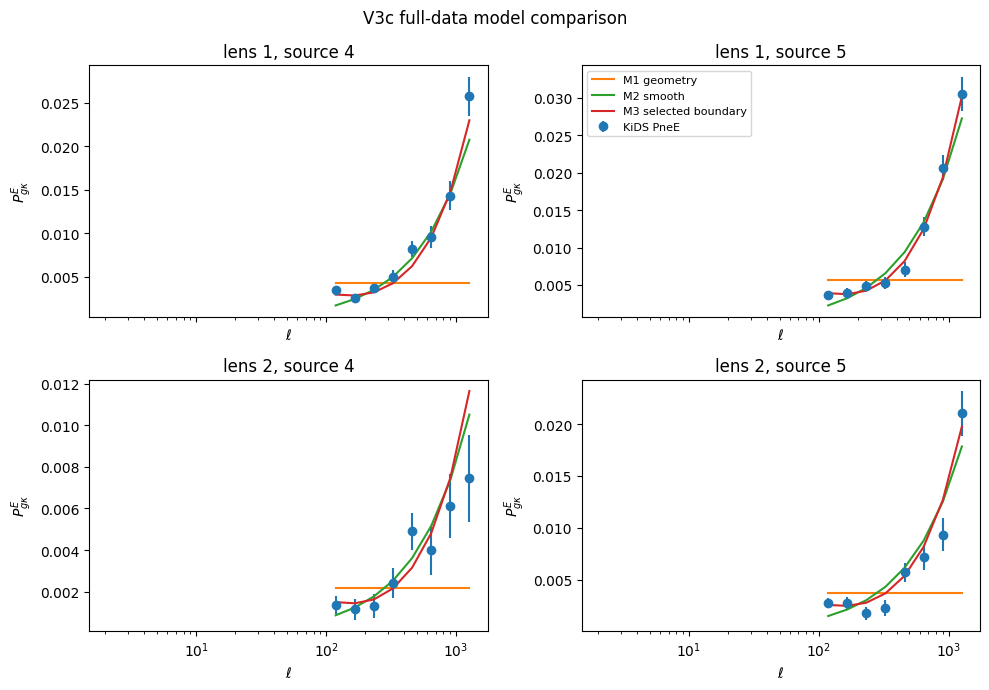

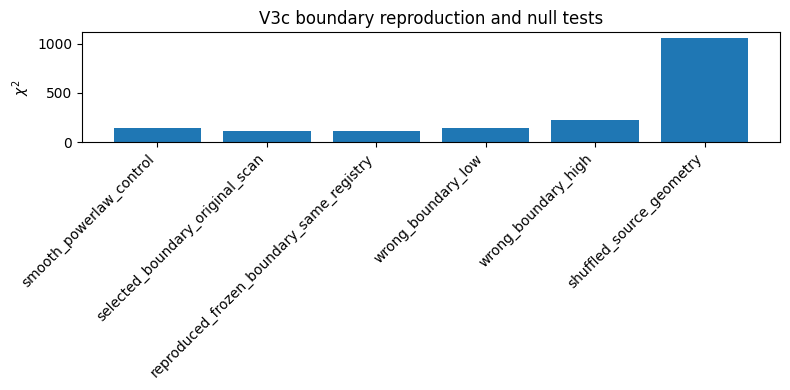

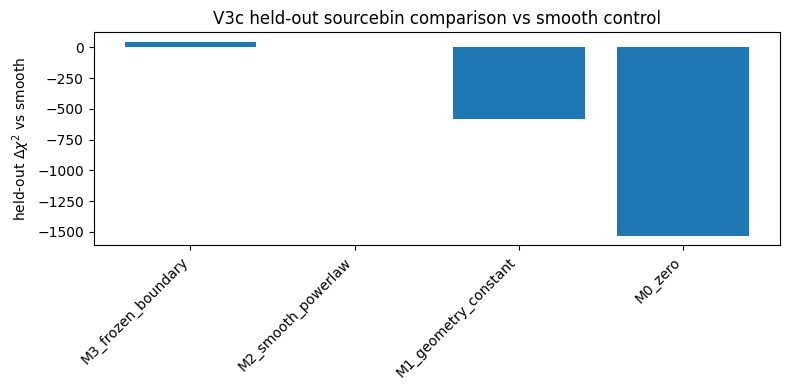

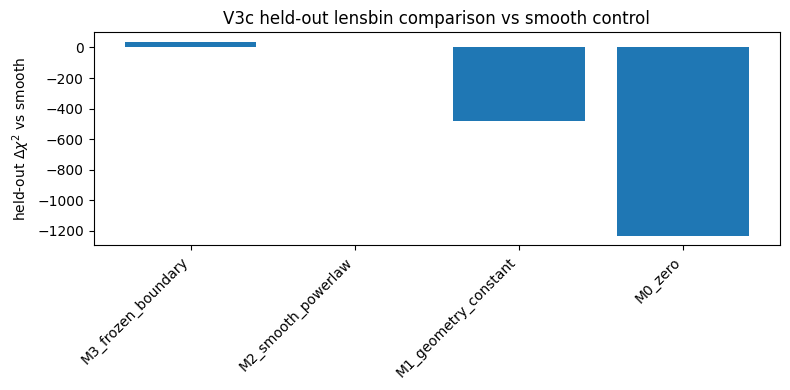

In [10]:
# CELL 09 — Figures

# Full-data comparison plots for high-source bins where signal is visible.
plot_specs = [(1,4),(1,5),(2,4),(2,5)]
fig, axes = plt.subplots(2,2,figsize=(10,7), sharex=True)
axes = axes.ravel()
for ax,(lb,sb) in zip(axes, plot_specs):
    m = (df2['lens_bin']==lb) & (df2['source_bin']==sb)
    order = np.argsort(ell[m])
    x = ell[m][order]
    ax.errorbar(x, y[m][order], yerr=df2['sigma_diag'].to_numpy()[m][order], fmt='o', label='KiDS PneE')
    ax.plot(x, pred_m1[m][order], label='M1 geometry')
    ax.plot(x, pred_m2[m][order], label='M2 smooth')
    ax.plot(x, pred_m3[m][order], label='M3 selected boundary')
    ax.set_xscale('log')
    ax.set_title(f'lens {lb}, source {sb}')
    ax.set_xlabel(r'$\ell$')
    ax.set_ylabel(r'$P_{g\kappa}^E$')
axes[1].legend(fontsize=8)
plt.suptitle('V3c full-data model comparison')
plt.tight_layout()
plt.savefig(FIG/'v3c_full_data_model_comparison.png', dpi=180)
plt.show()

# Bar charts for null and held-out summaries.
plt.figure(figsize=(8,4))
plt.bar(null_df['test'], null_df['chi2'])
plt.xticks(rotation=45, ha='right')
plt.ylabel(r'$\chi^2$')
plt.title('V3c boundary reproduction and null tests')
plt.tight_layout()
plt.savefig(FIG/'v3c_boundary_reproduction_and_null_tests.png', dpi=180)
plt.show()

for name, summ in [('sourcebin', source_cv_summary), ('lensbin', lens_cv_summary)]:
    plt.figure(figsize=(8,4))
    plt.bar(summ['model'], summ['total_delta_chi2_vs_smooth'])
    plt.xticks(rotation=45, ha='right')
    plt.ylabel(r'held-out $\Delta\chi^2$ vs smooth')
    plt.title(f'V3c held-out {name} comparison vs smooth control')
    plt.tight_layout()
    plt.savefig(FIG/f'v3c_heldout_{name}_vs_smooth.png', dpi=180)
    plt.show()


In [11]:
# CELL 10 — Write README, manifest, and download ZIP

manifest = {
    'run_label': RUN_LABEL,
    'source_repo_zip_url': REPO_ZIP_URL,
    'source_fits': str(FITS_PATH),
    'observable': 'KiDS-1000 PneE interpreted as Pgk E-mode galaxy-galaxy lensing bandpower',
    'N_points': int(len(df2)),
    'covariance_shape': list(cov.shape),
    'ell_min': float(df2['ell'].min()),
    'ell_max': float(df2['ell'].max()),
    'ell0': ell0,
    'frozen_boundary': FROZEN_BOUNDARY,
    'low_ram_fix': 'streaming boundary scan; no full-grid DataFrame/list retained',
}
with open(OUT/'manifest.json', 'w') as f:
    json.dump(manifest, f, indent=2)

readme = f'''# {RUN_LABEL}

## Purpose

V3c is a low-RAM fixed-registry reproduction notebook for the KiDS-1000 PneE boundary-response test.

The previous crash came from storing every nested boundary trial in memory. V3c streams the nested scan and keeps only the best model plus a small top-N audit table.

## Dataset

- Observable: KiDS-1000 `PneE`, interpreted as $P_{{g\kappa}}^E(\ell)$
- Data points: {len(df2)}
- Lens bins: {df2['lens_bin'].nunique()}
- Source bins: {df2['source_bin'].nunique()}
- Ell bins: {df2['ell_bin'].nunique()}
- Ell range: {df2['ell'].min():.6f} to {df2['ell'].max():.6f}
- Covariance shape: {cov.shape}
- Covariance condition number: {condition_positive:.3f}

## Frozen boundary selected by registry

```json
{json.dumps(FROZEN_BOUNDARY, indent=2)}
```

## Full-data competition

{res_df.to_markdown(index=False)}

## Boundary reproduction and null tests

{null_df.to_markdown(index=False)}

## Held-out source-bin validation

{source_cv_summary.to_markdown(index=False)}

## Held-out lens-bin validation

{lens_cv_summary.to_markdown(index=False)}

## Interpretation guardrail

This is still not a first-principles ECSM baryonic-driver projection integral. It is a covariance-aware boundary-response shape/transfer test.
'''
(OUT/'README.md').write_text(readme)
print(readme)

zip_path = BASE / f'{RUN_LABEL}_outputs.zip'
if zip_path.exists():
    zip_path.unlink()
shutil.make_archive(str(zip_path).replace('.zip',''), 'zip', OUT)
print('ZIP ready:', zip_path)
print('Size MB:', zip_path.stat().st_size/1e6)

# Copy to Google Drive if mounted.
drive_dir = Path('/content/drive/MyDrive/ECSM_KiDS_data')
if Path('/content/drive/MyDrive').exists():
    drive_dir.mkdir(parents=True, exist_ok=True)
    dst = drive_dir / zip_path.name
    shutil.copy2(zip_path, dst)
    print('Copied to Drive:', dst)
else:
    print('Drive not mounted. To save to Drive, run: from google.colab import drive; drive.mount("/content/drive")')

try:
    from google.colab import files
    files.download(str(zip_path))
except Exception as e:
    print('Manual download path:', zip_path)
    print('files.download unavailable outside Colab:', e)


<>:63: SyntaxWarning: invalid escape sequence '\k'
<>:63: SyntaxWarning: invalid escape sequence '\e'
<>:63: SyntaxWarning: invalid escape sequence '\k'
<>:63: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_30312/2826179610.py:63: SyntaxWarning: invalid escape sequence '\k'
  '''
/tmp/ipykernel_30312/2826179610.py:63: SyntaxWarning: invalid escape sequence '\e'
  '''


# ECSM_KiDS_Pgk_Boundary_Response_V3c_LowRAM_FixedRegistry

## Purpose

V3c is a low-RAM fixed-registry reproduction notebook for the KiDS-1000 PneE boundary-response test.

The previous crash came from storing every nested boundary trial in memory. V3c streams the nested scan and keeps only the best model plus a small top-N audit table.

## Dataset

- Observable: KiDS-1000 `PneE`, interpreted as $P_{g\kappa}^E(\ell)$
- Data points: 80
- Lens bins: 2
- Source bins: 5
- Ell bins: 8
- Ell range: 118.441992 to 1266.442730
- Covariance shape: (80, 80)
- Covariance condition number: 135.580

## Frozen boundary selected by registry

```json
{
  "kind": "high_suppression",
  "ell_B": 77.86226983114605,
  "p": 3.0,
  "B": -0.9
}
```

## Full-data competition

| model                | family                 |     chi2 |   n_params | params                                                                                                                                                              

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>